In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

In [7]:
from src.utils.box import calculate_concept_heights
with open(JSON_PATH, 'r') as f:
    data = json.load(f)
concept_heights = calculate_concept_heights(concept2id, data)

AllenNLP not available. Registrable won't work.


### Train

In [8]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

In [9]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 55 concetti unici e 633 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.6128
Epoca [10/100] | Loss: 0.2104
Epoca [20/100] | Loss: 0.0609
Epoca [30/100] | Loss: 0.0248
Epoca [40/100] | Loss: 0.0134
Epoca [50/100] | Loss: 0.0085
Epoca [60/100] | Loss: 0.0062
Epoca [70/100] | Loss: 0.0052
Epoca [80/100] | Loss: 0.0046
Epoca [90/100] | Loss: 0.0041
Epoca [100/100] | Loss: 0.0039

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: leg | hops
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [10]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

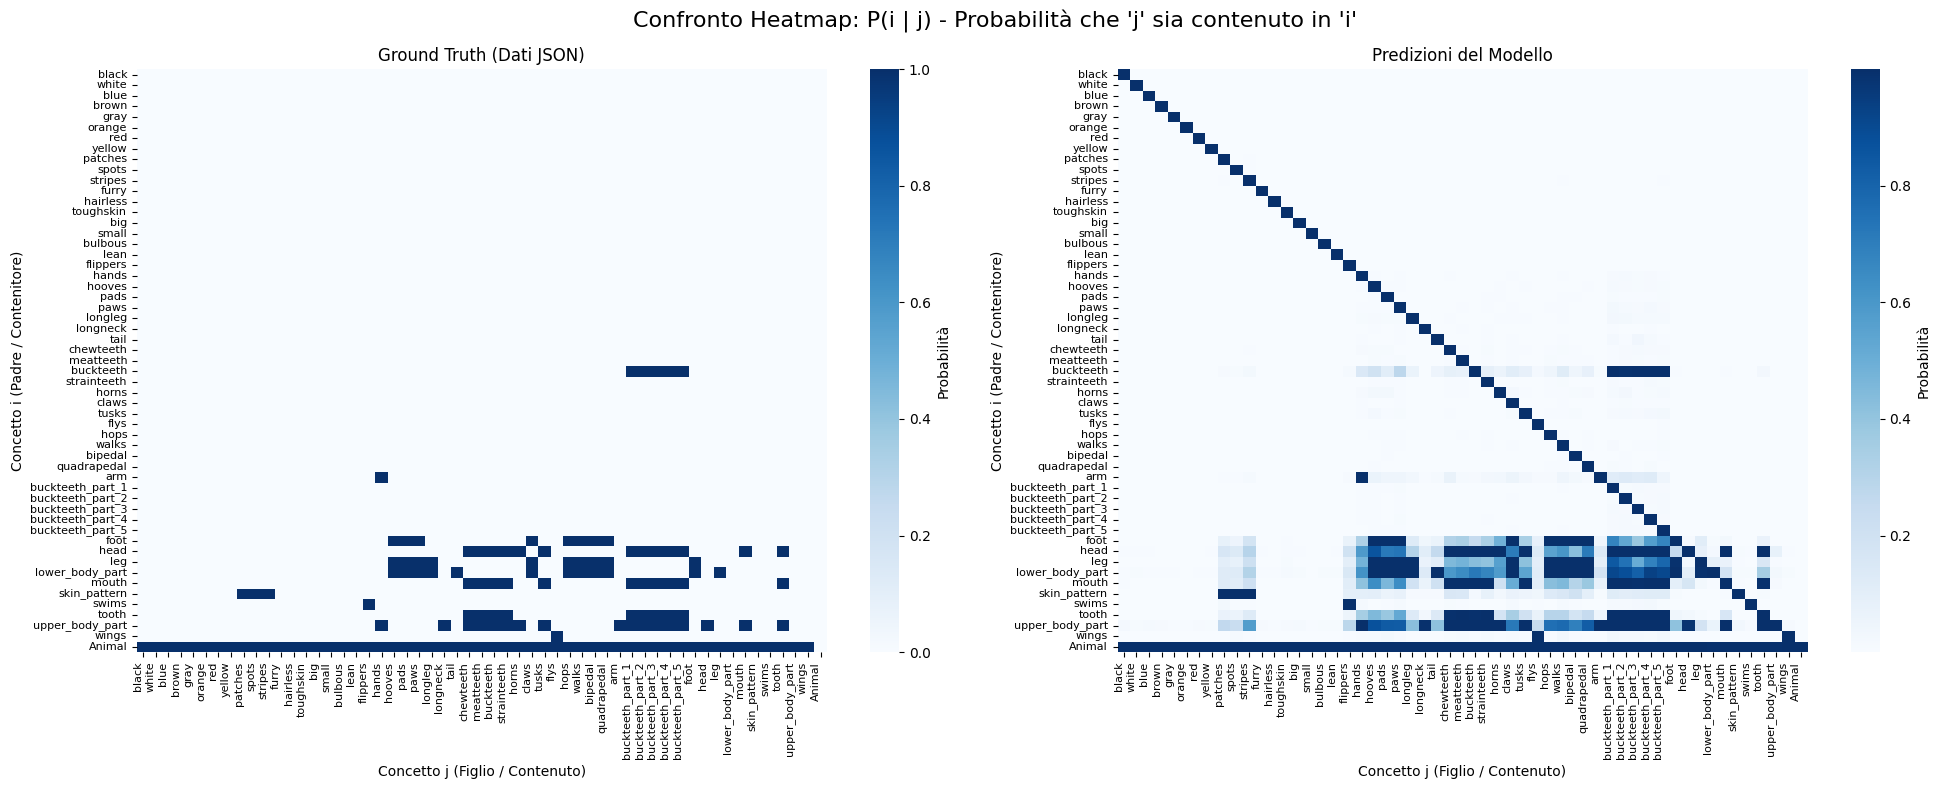

In [11]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

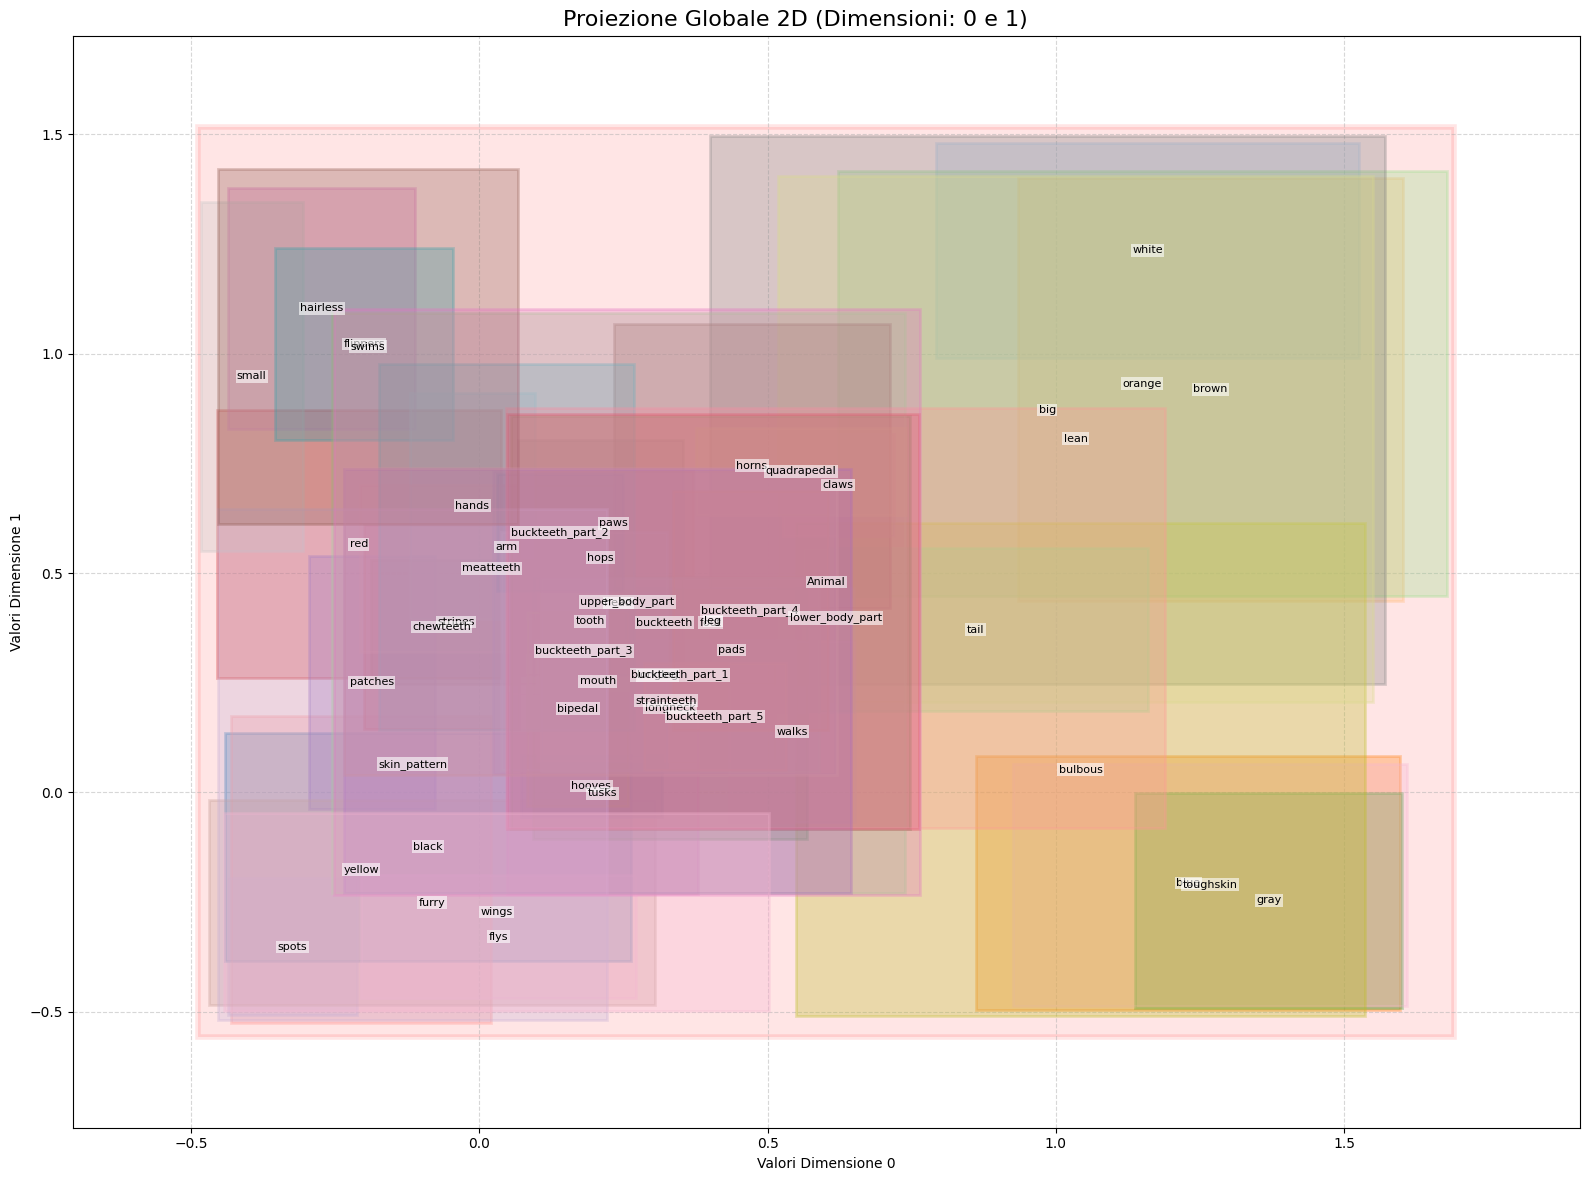

In [12]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

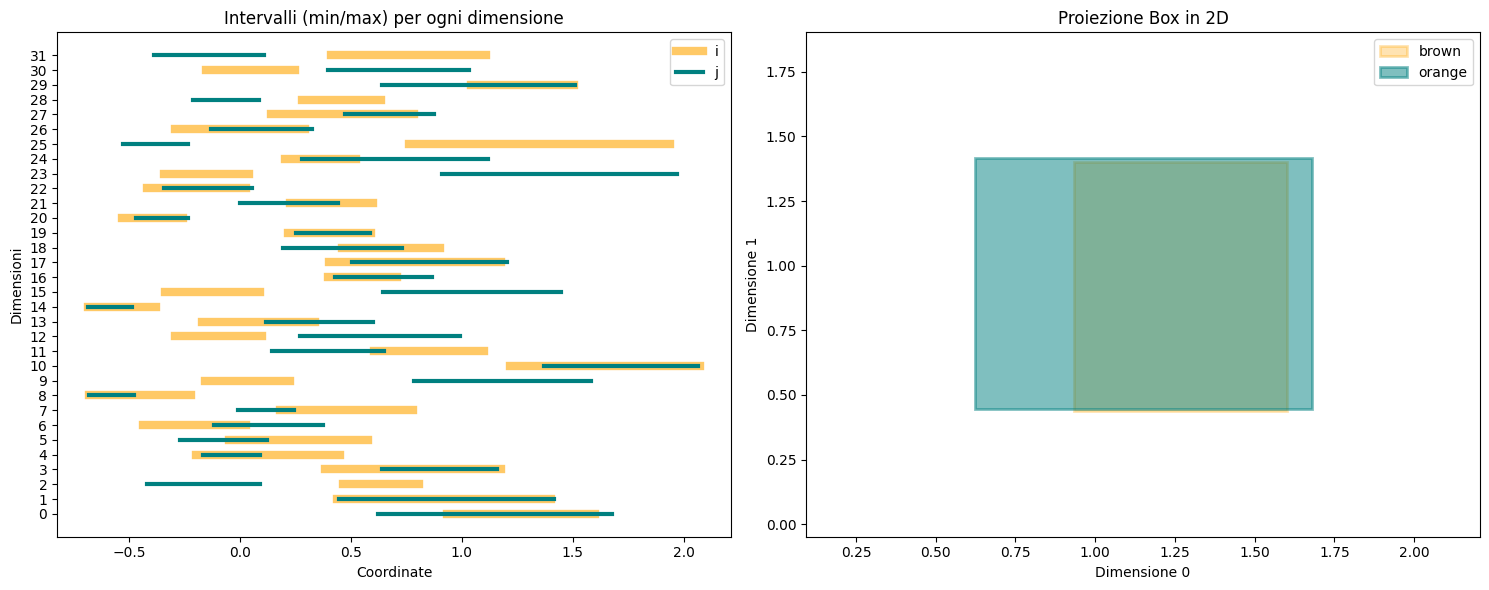

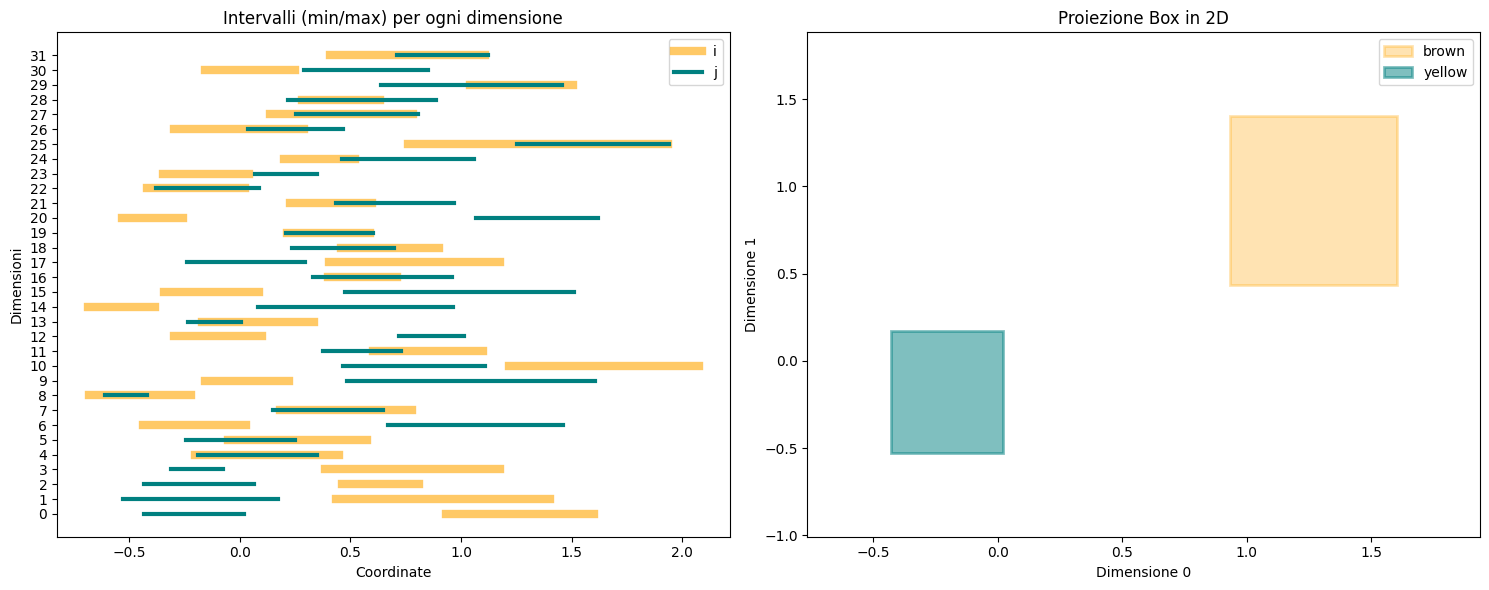

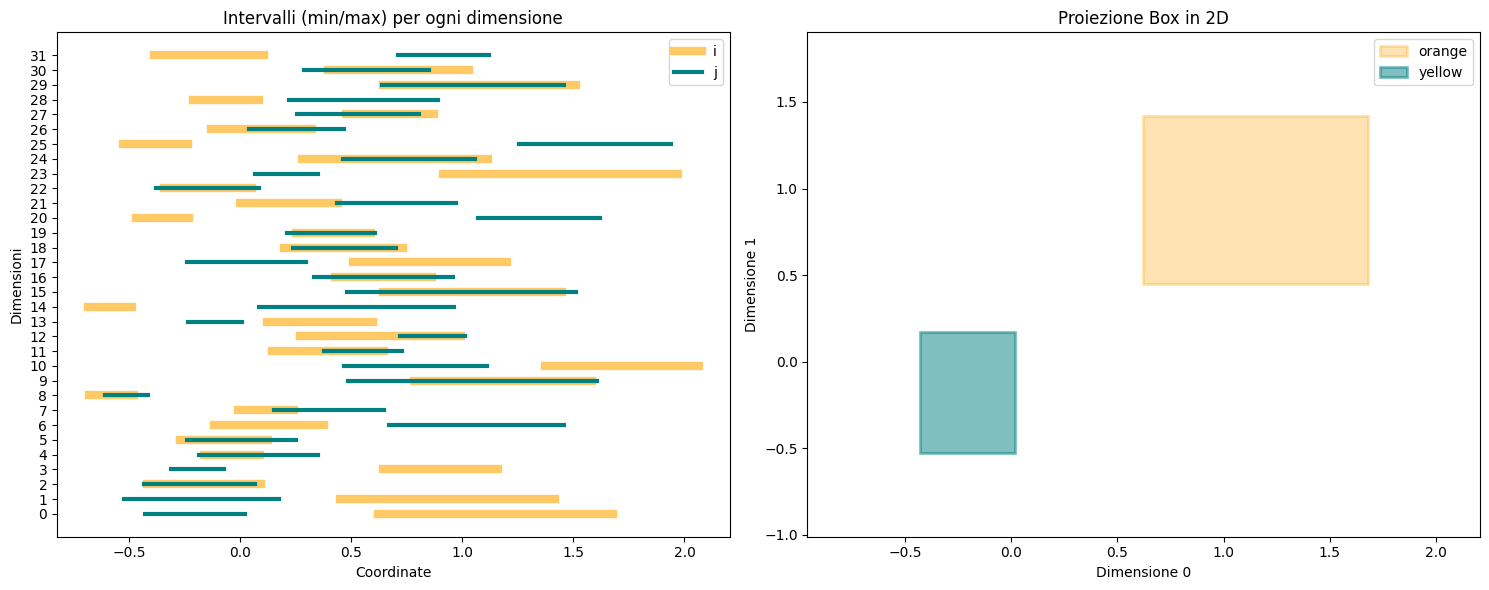

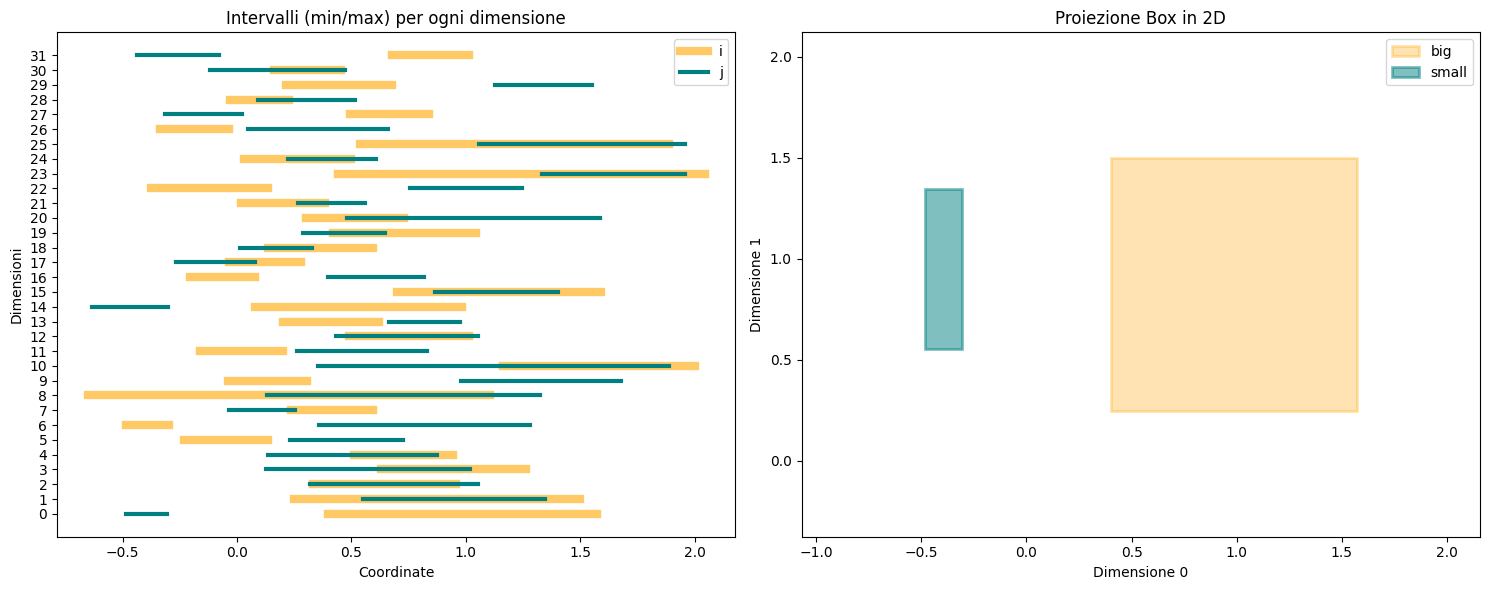

In [13]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [14]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [19]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import joint_training
import matplotlib.pyplot as plt
from src.CHM.test import test_joint_cbm
from src.utils.plot import plot_history, plot_test_results, plot_concept_error_heatmap, plot_concept_uncertainty_heatmap, plot_intervention_curve, analyze_misclassifications_concepts

### CBM with boxes

#### Train

In [20]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)

b_optimizer = torch.optim.Adam(list(b_cls.parameters()) + list(b_concept_predictor.parameters()), lr=0.0005)

lambda_concept = 1.5
gamma_hierarchy = 1

info = "boxes"

b_history = joint_training(
    classifier=b_cls,
    concept_predictor=b_concept_predictor,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    optimizer=b_optimizer,
    criterion_cls=b_cls_criterion,
    concept_heights=concept_heights,
    epochs=7,
    device=device,
    lambda_c=lambda_concept,
    gamma_h=gamma_hierarchy,
    info=info,
    bipolar=False,
)


========== Addestramento Joint CBM (con Logica Gerarchica) ==========
Epoca   1/7 | Acc Train: 76.2% | Acc Val: 89.3%
  TRAIN -> Tot: 1.6469 [Cls: 0.9544 | C: 0.3669 | H: 0.1422]
  VAL   -> Tot: 0.9804 [Cls: 0.3769 | C: 0.2985 | H: 0.1558]

Epoca   2/7 | Acc Train: 91.5% | Acc Val: 90.5%
  TRAIN -> Tot: 0.8560 [Cls: 0.2880 | C: 0.2841 | H: 0.1419]
  VAL   -> Tot: 0.8743 [Cls: 0.3224 | C: 0.2737 | H: 0.1415]

Epoca   3/7 | Acc Train: 93.7% | Acc Val: 90.5%
  TRAIN -> Tot: 0.7418 [Cls: 0.2059 | C: 0.2634 | H: 0.1408]
  VAL   -> Tot: 0.8537 [Cls: 0.3206 | C: 0.2625 | H: 0.1394]

Epoca   4/7 | Acc Train: 94.9% | Acc Val: 90.9%
  TRAIN -> Tot: 0.6820 [Cls: 0.1618 | C: 0.2540 | H: 0.1392]
  VAL   -> Tot: 0.8360 [Cls: 0.3116 | C: 0.2657 | H: 0.1260]

Epoca   5/7 | Acc Train: 96.0% | Acc Val: 90.1%
  TRAIN -> Tot: 0.6373 [Cls: 0.1276 | C: 0.2471 | H: 0.1391]
  VAL   -> Tot: 0.8425 [Cls: 0.3250 | C: 0.2598 | H: 0.1278]

Epoca   6/7 | Acc Train: 96.4% | Acc Val: 90.0%
  TRAIN -> Tot: 0.6128 [Cl

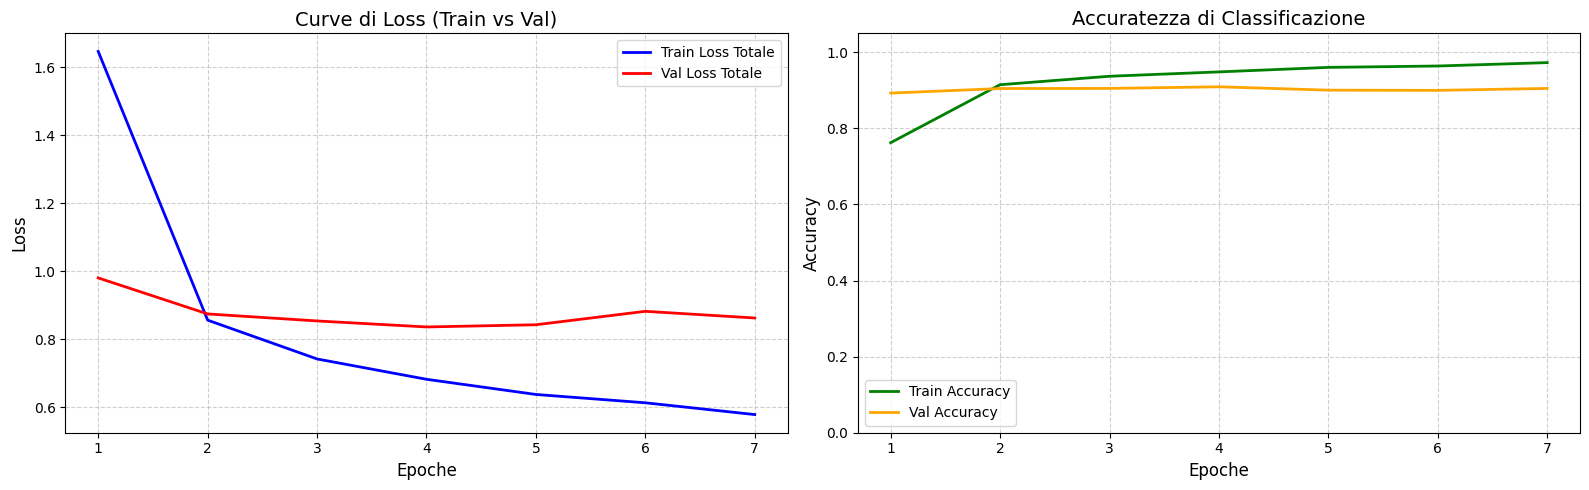

In [21]:
plot_history(b_history)

#### Test

In [22]:
accuracy, preds, labels, concept_preds, concept_trues, concept_probs = test_joint_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)


Inizio valutazione sul Test Set (Modalità Joint)...
Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.93% (6788/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       209
           1       0.85      0.98      0.91       170
           2       0.89      0.84      0.87        58
           3       0.70      0.50      0.58        38
           4       0.90      0.99      0.94       110
           5       0.89      0.94      0.92       149
           6       0.96      0.94      0.95       329
           7       0.83      0.93      0.88       207
           8       0.60      0.09      0.15        35
           9       0.94      0.81      0.87       100

   micro avg       0.89      0.90      0.90      1405
   macro avg       0.85      0.79      0.80      1405
weighted avg       0.89      0.90      0.89      1405



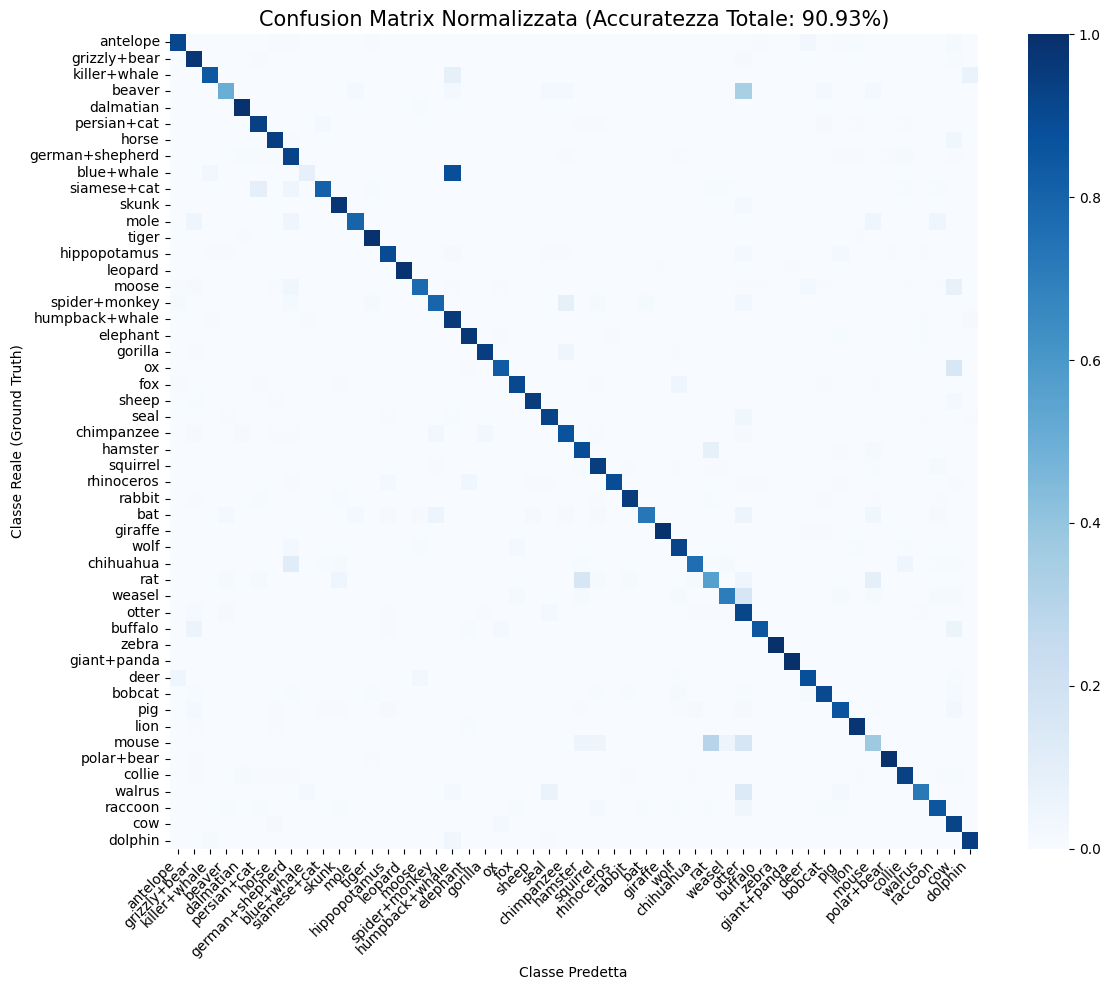


Analisi degli Errori Principali:
 - 31 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 23 volte: 'ox' è stato scambiato per 'cow'
 - 14 volte: 'hamster' è stato scambiato per 'rat'
 - 13 volte: 'chihuahua' è stato scambiato per 'german+shepherd'
 - 13 volte: 'horse' è stato scambiato per 'cow'


In [23]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

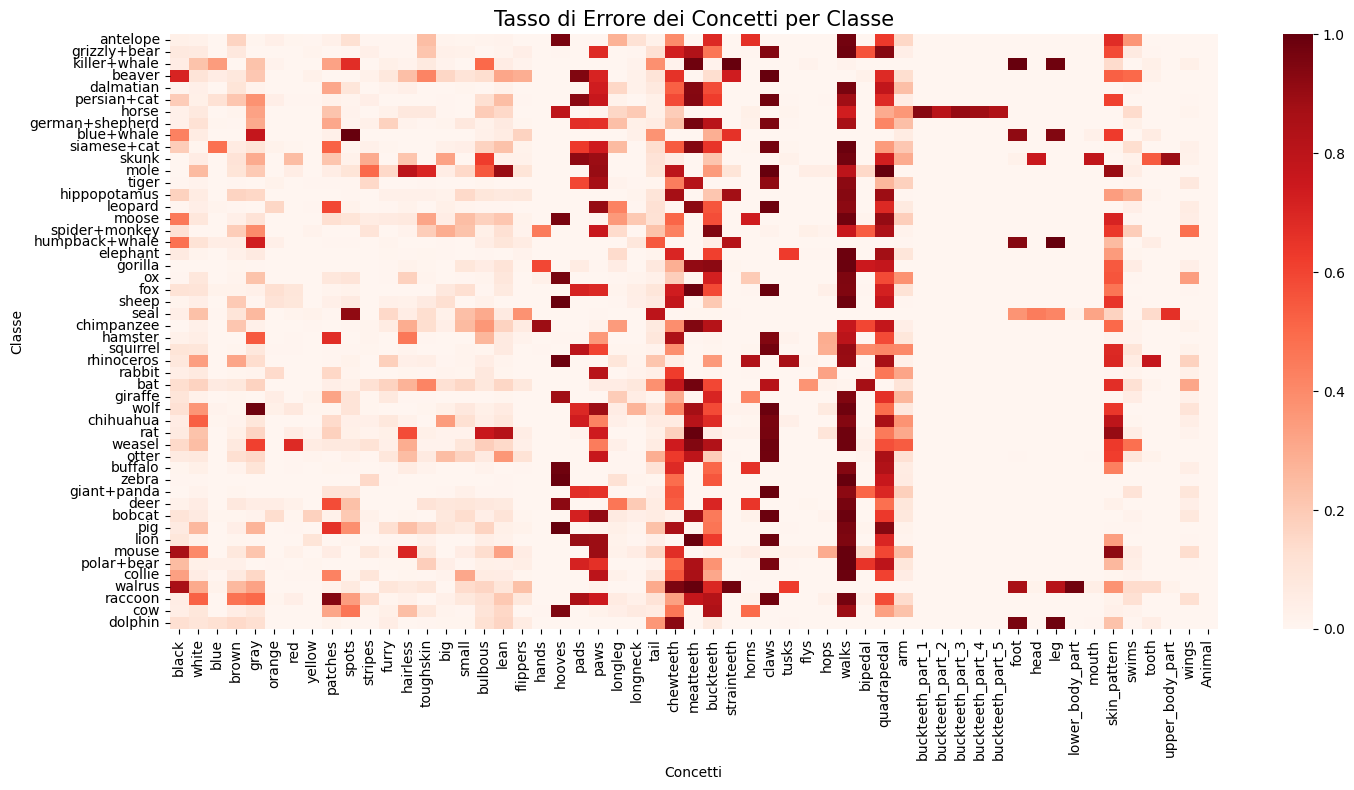

In [24]:
plot_concept_error_heatmap(labels, concept_preds, concept_trues, classes, concepts)

In [25]:
analyze_misclassifications_concepts(preds, labels, concept_preds, concept_trues, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'grizzly+bear'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [chewteeth] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [meatteeth] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [buckteeth] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [walks] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [quadrapedal] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [skin_pattern] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.

[Es

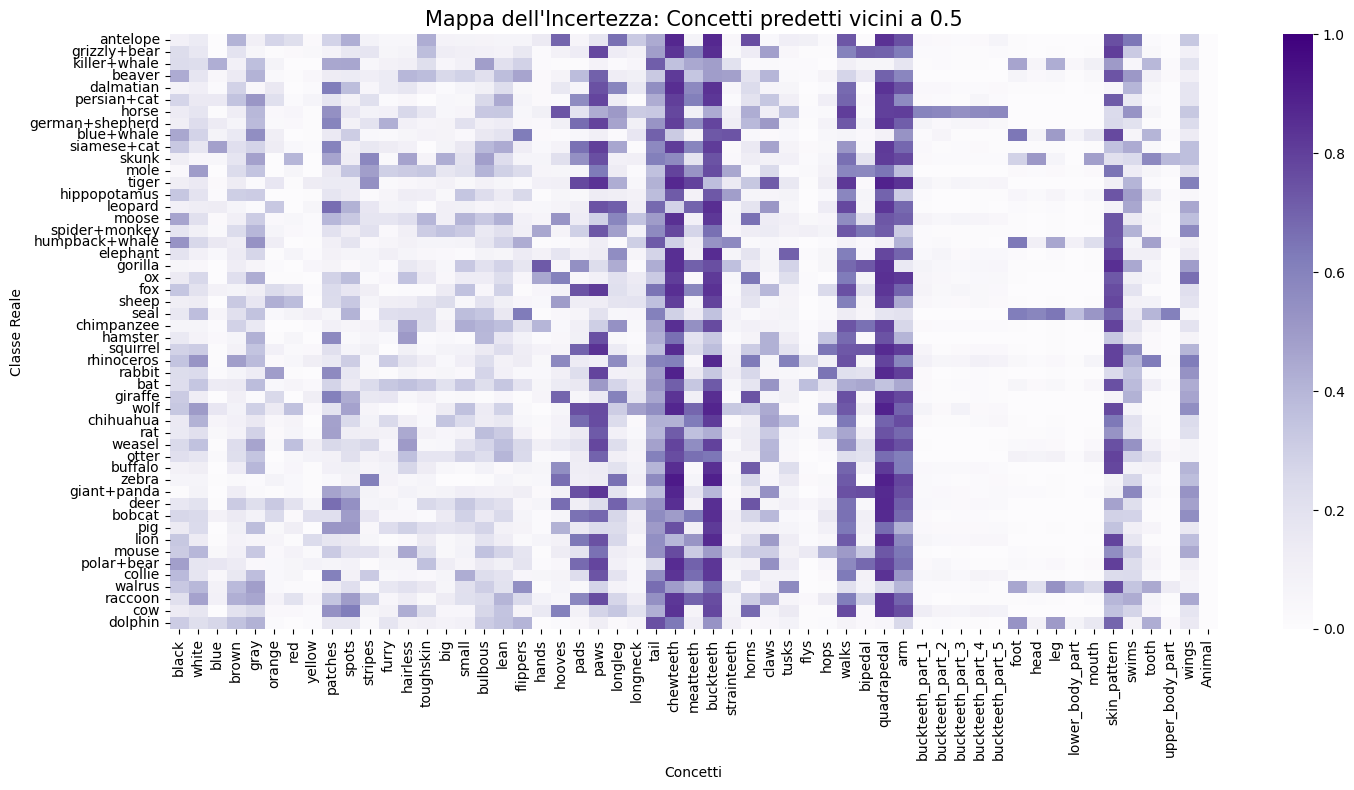

array([[9.92367119e-02, 1.44388437e-01, 5.30644367e-03, ...,
        1.04935549e-03, 3.28928024e-01, 3.77532968e-04],
       [2.30833635e-01, 1.64457083e-01, 7.25495582e-03, ...,
        4.01318213e-03, 9.84239802e-02, 8.82674649e-05],
       [2.39831671e-01, 2.24162191e-01, 4.28415805e-01, ...,
        1.73809212e-02, 2.01328963e-01, 6.27836271e-04],
       ...,
       [2.10848749e-01, 4.69833136e-01, 9.70861614e-02, ...,
        1.33799603e-02, 4.52015847e-01, 1.27423045e-04],
       [1.37570724e-01, 1.73426762e-01, 1.90507318e-03, ...,
        1.31825008e-03, 1.79097652e-01, 1.70018684e-04],
       [3.09704959e-01, 2.22085148e-01, 2.63775557e-01, ...,
        3.26574072e-02, 1.48465529e-01, 4.90256702e-04]])

In [26]:
plot_concept_uncertainty_heatmap(labels, concept_probs, class_names=classes, concept_names=concepts)

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_optimizer = torch.optim.Adam(list(cp_cls.parameters()) + list(cp_concept_predictor.parameters()), lr=0.001)

cp_cls_history = joint_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,
    cp_criterion,
    concept_heights,
    EPOCHS, 
    device,
    lambda_concept,
    gamma_hierarchy,
    info,
    bipolar=False,
)

In [ ]:
plot_history(cp_cls_history)

#### Test

In [ ]:
cp_accuracy, cp_preds, cp_labels = test_joint_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [ ]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_optimizer = torch.optim.Adam(list(c_cls.parameters()) + list(c_concept_predictor.parameters()), lr=0.001)

c_cls_history = joint_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,
    c_criterion,
    concept_heights,
    EPOCHS, 
    device,
    lambda_concept,
    gamma_hierarchy,
    info,
    bipolar=False,
)

In [ ]:
from src.utils.plot import plot_history
plot_history(c_cls_history)

In [ ]:
c_accuracy, c_preds, c_labels = test_joint_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)